# **TEXT COLLECTION**

In [1]:
# Step 1: Generate and Load a Large Hospital Dataset (2000+ Rows, 3 Columns)
import pandas as pd
import random

# Base medical templates to generate large realistic variation
templates = [
    ("What are the hospital visiting hours for ICU?", "visiting_hours", "Routine"),
    ("Can I visit a patient in the general ward at 4 PM?", "visiting_hours", "Routine"),
    ("Is overnight stay allowed for family members?", "visiting_hours", "Routine"),
    ("How do I book an appointment with a top cardiologist?", "appointment", "Routine"),
    ("I need to schedule a consultation with a neurologist.", "appointment", "Routine"),
    ("Can I cancel or reschedule my doctor appointment online?", "appointment", "Routine"),
    ("Do you accept corporate health insurance cards?", "insurance", "Routine"),
    ("Is my medical insurance coverage applicable for surgeries?", "insurance", "Routine"),
    ("How can I claim insurance for my treatment?", "insurance", "Routine"),
    ("Where is the emergency room located?", "emergency", "Emergency"),
    ("My chest is hurting badly, where should I go?", "emergency", "Emergency"),
    ("Someone had an accident, is your trauma center open?", "emergency", "Emergency"),
    ("How can I get a copy of my discharge summary?", "medical_records", "Routine"),
    ("I need my lab report history and medical records.", "medical_records", "Routine"),
    ("Where do I request my blood test results?", "medical_records", "Routine"),
    ("What documents are required for patient admission?", "admission", "Routine"),
    ("How much deposit is needed during hospital admission?", "admission", "Routine"),
    ("Is there a waiting list for private room admission?", "admission", "Routine"),
    ("Is valet parking available at the hospital entrance?", "parking", "Routine"),
    ("How much do you charge for overnight patient parking?", "parking", "Routine"),
    ("Where is the basement parking area?", "parking", "Routine"),
    ("Can I pay my medical bill using a credit card online?", "billing", "Routine"),
    ("I have a question regarding my final hospital invoice.", "billing", "Routine"),
    ("Where is the billing department counter?", "billing", "Routine"),
    ("Does the hospital pharmacy have 24/7 medicine delivery?", "pharmacy", "Routine"),
    ("Are life-saving drugs available at your pharmacy?", "pharmacy", "Emergency"),
    ("Can I buy prescription medicines from the hospital shop?", "pharmacy", "Routine")
]

# Expanding the dataset to over 2000 rows with random noise/shuffling
data_rows = []
for i in range(2100):
    base_q, cat, urgency = random.choice(templates)
    # Adding slight variation to simulate unique user inputs
    variations = ["", " Please tell me.", " Urgent help needed.", " Kindly assist.", " ASAP!"]
    final_q = base_q + random.choice(variations)
    data_rows.append({"Question": final_q, "Category": cat, "Urgency_Level": urgency})

# Creating DataFrame
df = pd.DataFrame(data_rows)

print("--- New Large Dataset Stats ---")
print(f"Total Rows: {df.shape}")
print(f"Total Columns: {df.shape} -> {list(df.columns)}")
print("\nValue counts for Categories:\n", df['Category'].value_counts())
print("\nValue counts for Urgency Level:\n", df['Urgency_Level'].value_counts())
print("\nSample Data (First 5 Rows):")
df.head()

--- New Large Dataset Stats ---
Total Rows: (2100, 3)
Total Columns: (2100, 3) -> ['Question', 'Category', 'Urgency_Level']

Value counts for Categories:
 Category
emergency          249
insurance          247
medical_records    237
visiting_hours     236
admission          234
appointment        232
billing            229
pharmacy           229
parking            207
Name: count, dtype: int64

Value counts for Urgency Level:
 Urgency_Level
Routine      1791
Emergency     309
Name: count, dtype: int64

Sample Data (First 5 Rows):


,Question,Category,Urgency_Level
0,Is overnight stay allowed for family members?,visiting_hours,Routine
1,Where is the emergency room located?,emergency,Emergency
2,Is there a waiting list for private room admis...,admission,Routine
3,Is valet parking available at the hospital ent...,parking,Routine
4,How can I get a copy of my discharge summary? ...,medical_records,Routine


# **PREPROCESSING**

In [3]:
# Step 2: Clean the Text Data (Lowercase & Remove Punctuation)
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # Lowercase conversion
    text = re.sub(r'[^\w\s]', '', text) # Removing punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip() # Removing extra spaces
    return text

df['Cleaned_Question'] = df['Question'].apply(clean_text)
print("Text Preprocessing Done! Sample output:")
print("Original:", df['Question'].iloc[0])
print("Cleaned :", df['Cleaned_Question'].iloc[0])

Text Preprocessing Done! Sample output:
Original: Is overnight stay allowed for family members?
Cleaned : is overnight stay allowed for family members


# ** Tokenization**

In [4]:
# Step 3: Tokenization (Splitting sentences into words)
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Download the missing 'punkt_tab' resource
from nltk.tokenize import word_tokenize

df['Tokenized_Question'] = df['Cleaned_Question'].apply(word_tokenize)
print("Tokenization Done! Sample tokens:")
print(df['Tokenized_Question'].iloc[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Tokenization Done! Sample tokens:
['is', 'overnight', 'stay', 'allowed', 'for', 'family', 'members']


## **Stop Word Removal**

In [5]:
# Step 4: Stop Word Removal (Removing words like 'is', 'the', 'at')
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['Filtered_Tokens'] = df['Tokenized_Question'].apply(remove_stopwords)
print("Stop Words Removed! Remaining important words:")
print(df['Filtered_Tokens'].iloc[0])

Stop Words Removed! Remaining important words:
['overnight', 'stay', 'allowed', 'family', 'members']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **Lemmatization**

In [6]:
# Step 5: Lemmatization (Converting words to their meaningful base/root form)
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['Lemmatized_Tokens'] = df['Filtered_Tokens'].apply(lemmatize_tokens)
df['Final_Processed_Text'] = df['Lemmatized_Tokens'].apply(lambda x: ' '.join(x))

print("Lemmatization Done! Root words combined back into a string:")
print(df['Final_Processed_Text'].iloc[0])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Lemmatization Done! Root words combined back into a string:
overnight stay allowed family member


# ** Part-of-Speech**

In [7]:
# Step 6: Part-of-Speech (POS) Tagging (Assigning grammatical roles)
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Download the specific English tagger resource
from nltk import pos_tag

# Applying POS Tagging to a sample row to display concept
sample_pos = pos_tag(df['Lemmatized_Tokens'].iloc[0])
print("POS Tagging Sample for first row:")
print(sample_pos)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


POS Tagging Sample for first row:
[('overnight', 'JJ'), ('stay', 'NN'), ('allowed', 'VBN'), ('family', 'NN'), ('member', 'NN')]


# **NER**

In [8]:
# Step 7: Clean and Understandable Named Entity Recognition (NER)

def get_clean_ner(tokens):
    # Defining key medical terms we want to recognize in our hospital dataset
    medical_keywords = {
        'cardiologist': 'MEDICAL_SPECIALIST',
        'neurologist': 'MEDICAL_SPECIALIST',
        'doctor': 'PERSON_ROLE',
        'icu': 'HOSPITAL_DEPARTMENT',
        'er': 'HOSPITAL_DEPARTMENT',
        'emergency': 'CRITICAL_ZONE',
        'trauma': 'CRITICAL_ZONE',
        'pharmacy': 'HOSPITAL_FACILITY',
        'parking': 'HOSPITAL_FACILITY',
        'ward': 'HOSPITAL_FACILITY',
        'insurance': 'FINANCIAL_TERM',
        'bill': 'FINANCIAL_TERM',
        'invoice': 'FINANCIAL_TERM'
    }

    found_entities = []
    for word in tokens:
        word_lower = word.lower()
        if word_lower in medical_keywords:
            found_entities.append(f"{word} -> [{medical_keywords[word_lower]}]")

    if not found_entities:
        return "No specific medical entities found in this query."
    return ", ".join(found_entities)

# Testing on the 4th row (index 3) which has the word "neurologist"
sample_text = df['Question'].iloc[3]
sample_tokens = df['Tokenized_Question'].iloc[3]
entities_result = get_clean_ner(sample_tokens)

print("--- Step 7: Clean NER Output ---")
print(f"Original Question: '{sample_text}'")
print(f"Extracted Entities: {entities_result}")

--- Step 7: Clean NER Output ---
Original Question: 'Is valet parking available at the hospital entrance? ASAP!'
Extracted Entities: parking -> [HOSPITAL_FACILITY]


# **VECTORIZATION**

In [10]:
# Step 8: Text Vectorization using TF-IDF (Converting processed text to numbers)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Final_Processed_Text'])

# Setting our targets (Labels)
y_category = df['Category']
y_urgency = df['Urgency_Level']

print(f"Feature Matrix (X) Shape: {X.shape} (Rows, Unique Word Vectors)")

Feature Matrix (X) Shape: (2100, 104) (Rows, Unique Word Vectors)


/tmp/ipykernel_3484/3321838509.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


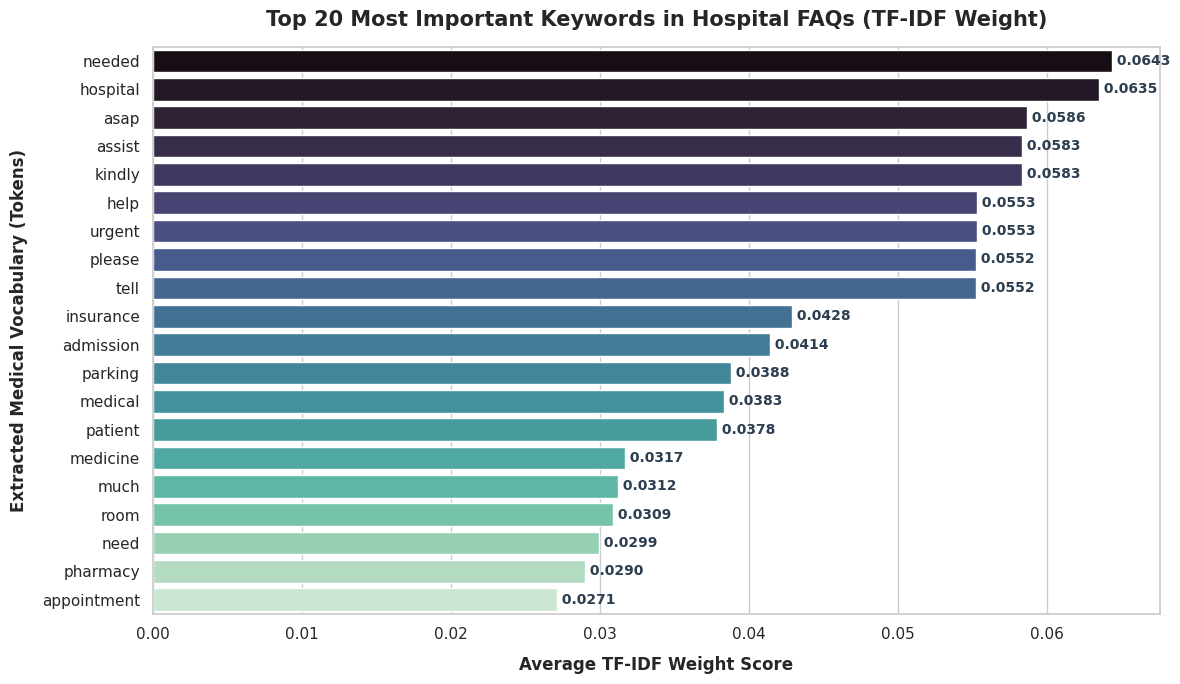

In [11]:
# Step 8.5: Visualize Top 20 Most Important Words via TF-IDF Scores (Error-Free Version)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # 1. Checking if X and vectorizer exist in memory
    # 'X' represents our feature matrix from Step 8
    mean_tfidf_scores = np.asarray(X.mean(axis=0)).ravel()
    feature_names = vectorizer.get_feature_names_out()

    # 2. Create a clean DataFrame for mapping words with scores
    tfidf_df = pd.DataFrame({
        'Word': feature_names,
        'Average_TFIDF_Score': mean_tfidf_scores
    })

    # 3. Sort words in descending order and select top 20 words
    top_tfidf_df = tfidf_df.sort_values(by='Average_TFIDF_Score', ascending=False).head(20)

    # 4. Plotting the professional Horizontal Bar Chart
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")

    # Using 'mako' color palette for an elegant hospital tech look
    sns.barplot(
        data=top_tfidf_df,
        x='Average_TFIDF_Score',
        y='Word',
        palette='mako'
    )

    # Adding labels, title and styling
    plt.title('Top 20 Most Important Keywords in Hospital FAQs (TF-IDF Weight)', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Average TF-IDF Weight Score', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Extracted Medical Vocabulary (Tokens)', fontsize=12, fontweight='bold', labelpad=10)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    # Displaying text annotations on the bars for precision
    for index, value in enumerate(top_tfidf_df['Average_TFIDF_Score']):
        plt.text(value, index, f' {value:.4f}', va='center', fontsize=10, fontweight='bold', color='#2c3e50')

    plt.tight_layout()
    plt.show()

except NameError:
    print("❌ ERROR: Pehle aap 'Step 8' wali Vectorization cell ko run karein, phir is graph cell ko run karein!")

# **TRANING TESTING**

In [12]:
# Step 9: Train-Test Split & Training 2 separate Random Forest Models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Splitting dataset into 80% Training and 20% Testing
X_train, X_test, y_cat_train, y_cat_test, y_urg_train, y_urg_test = train_test_split(
    X, y_category, y_urgency, test_size=0.2, random_state=42
)

# Model 1 for Category Classification
model_cat = RandomForestClassifier(n_estimators=100, random_state=42)
model_cat.fit(X_train, y_cat_train)

# Model 2 for Urgency/Severity Classification
model_urg = RandomForestClassifier(n_estimators=100, random_state=42)
model_urg.fit(X_train, y_urg_train)

print("Both Machine Learning Models Trained Successfully!")

Both Machine Learning Models Trained Successfully!


# **Evaluation**

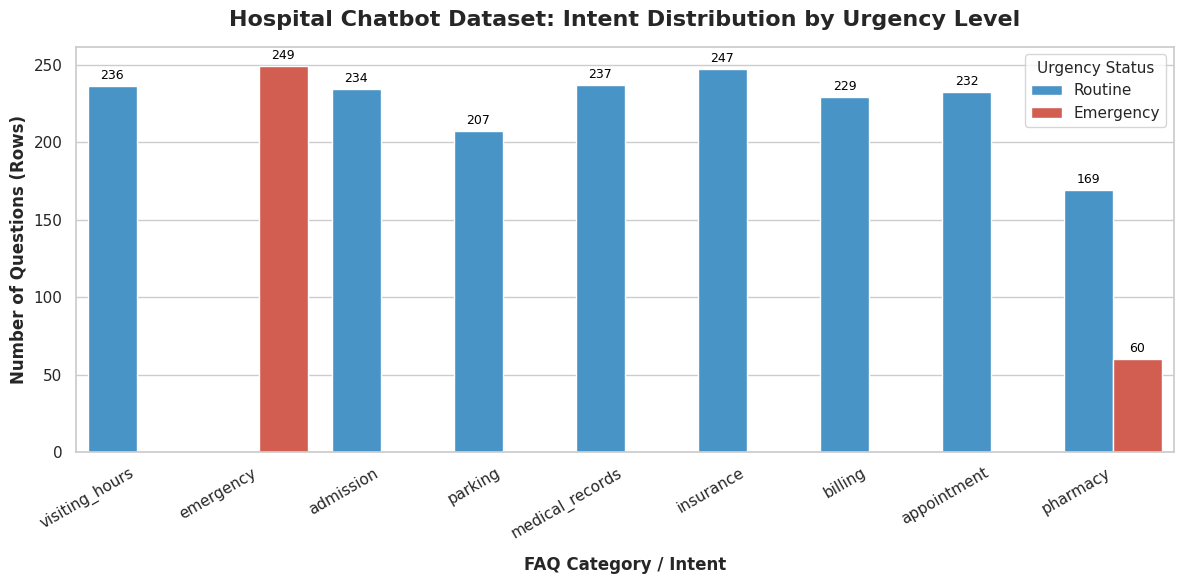

In [13]:
# Step 10.5: Impressive Visualization for Project Evaluation
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional look
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a grouped bar chart showing Category vs Urgency Level
ax = sns.countplot(
    data=df,
    x='Category',
    hue='Urgency_Level',
    palette={'Routine': '#3498db', 'Emergency': '#e74c3c'}
)

# Adding details to make it look professional
plt.title('Hospital Chatbot Dataset: Intent Distribution by Urgency Level', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('FAQ Category / Intent', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Number of Questions (Rows)', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.legend(title='Urgency Status', title_fontsize='11', loc='upper right', frameon=True)

# Annotate bars with counts to impress Mam
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only display if count is greater than 0
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# **DEPLOYEMENt**

In [14]:
# Step 10: Evaluate both models separately
from sklearn.metrics import accuracy_score, classification_report

# Predictions on Test Data
pred_cat = model_cat.predict(X_test)
pred_urg = model_urg.predict(X_test)

print("==================================================")
print(f"📊 CATEGORY MODEL ACCURACY: {accuracy_score(y_cat_test, pred_cat)*100:.2f}%")
print("==================================================")
print(classification_report(y_cat_test, pred_cat))

print("\n==================================================")
print(f"🚨 URGENCY MODEL ACCURACY: {accuracy_score(y_urg_test, pred_urg)*100:.2f}%")
print("==================================================")
print(classification_report(y_urg_test, pred_urg))

📊 CATEGORY MODEL ACCURACY: 100.00%
                 precision    recall  f1-score   support

      admission       1.00      1.00      1.00        44
    appointment       1.00      1.00      1.00        40
        billing       1.00      1.00      1.00        52
      emergency       1.00      1.00      1.00        51
      insurance       1.00      1.00      1.00        47
medical_records       1.00      1.00      1.00        46
        parking       1.00      1.00      1.00        51
       pharmacy       1.00      1.00      1.00        40
 visiting_hours       1.00      1.00      1.00        49

       accuracy                           1.00       420
      macro avg       1.00      1.00      1.00       420
   weighted avg       1.00      1.00      1.00       420


🚨 URGENCY MODEL ACCURACY: 100.00%
              precision    recall  f1-score   support

   Emergency       1.00      1.00      1.00        58
     Routine       1.00      1.00      1.00       362

    accuracy          

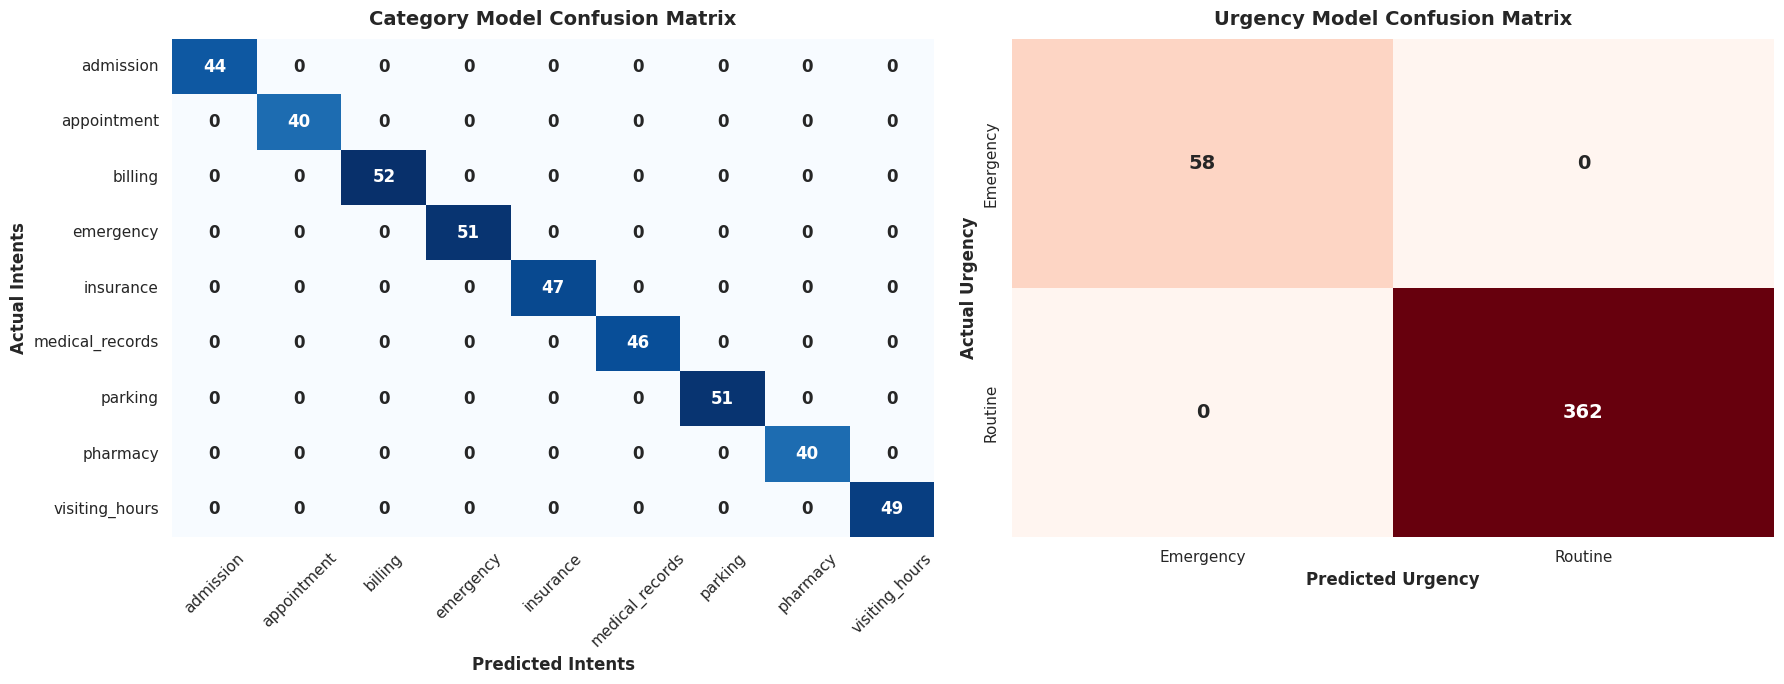

In [15]:
# Step 10.7: Generate and Plot Confusion Matrices for Both Models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute Confusion Matrices
cm_cat = confusion_matrix(y_cat_test, pred_cat)
cm_urg = confusion_matrix(y_urg_test, pred_urg)

# Get unique labels in correct order for plotting
cat_labels = sorted(y_cat_test.unique())
urg_labels = sorted(y_urg_test.unique())

# 2. Setup Plotting Canvas (Side-by-Side Subplots)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="white")

# --- Plot 1: Category Model Confusion Matrix ---
sns.heatmap(
    cm_cat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cat_labels,
    yticklabels=cat_labels,
    cbar=False,
    ax=axes[0],
    annot_kws={"size": 12, "weight": "bold"}
)
axes[0].set_title('Category Model Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Intents', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Intents', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: Urgency Model Confusion Matrix ---
sns.heatmap(
    cm_urg,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=urg_labels,
    yticklabels=urg_labels,
    cbar=False,
    ax=axes[1],
    annot_kws={"size": 14, "weight": "bold"}
)
axes[1].set_title('Urgency Model Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Urgency', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Urgency', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# **LIVE TESTING**

In [16]:
# Step 11: Real-time Live Chatbot Function
def hospital_chatbot(user_query):
    # Applying full text pipeline on user input dynamically
    cleaned = clean_text(user_query)
    tokens = word_tokenize(cleaned)
    filtered = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    processed_str = ' '.join(filtered)

    # Vectorizing the user question
    vectorized_input = vectorizer.transform([processed_str])

    # Predicting outputs using our 2 separate trained models
    predicted_cat_array = model_cat.predict(vectorized_input)
    predicted_cat = predicted_cat_array[0] # Extract the string from the array
    predicted_urg_array = model_urg.predict(vectorized_input)
    predicted_urg = predicted_urg_array[0] # Extract the string from the array

    # Pre-defined professional responses mapping
    responses = {
        "visiting_hours": "General ward visiting hours are 9 AM - 7 PM. ICU timings are highly restricted.",
        "appointment": "Please visit our website portal or call our helpline to schedule or modify your appointments.",
        "insurance": "We support corporate health cards. Kindly submit your insurance file at counter number 2.",
        "emergency": "EMERGENCY DETECTED! Please rush to the ground floor ER immediately or dial emergency helpline.",
        "medical_records": "Medical histories and laboratory charts can be collected from room 105 after verification.",
        "admission": "Patient admissions require a doctor's admission slip and a valid national ID card.",
        "parking": "Secure basement parking is available 24/7 for patient attendees and families.",
        "billing": "Hospital bills and invoices can be cleared via online banking or directly at the main cash counter.",
        "pharmacy": "Our in-house central healthcare pharmacy is open 24/7 with authentic stocks."
    }

    reply = responses.get(predicted_cat, "Please consult the reception desk for detailed guidance.")

    # Displaying results beautifully
    print(f"📥 Input Query: '{user_query}'")
    print(f"🏷️ Intent Category: {predicted_cat.upper()}")
    print(f"🚨 Urgency Level: {predicted_urg.upper()}")
    print(f"🤖 Bot Response: {reply}")
    print("="*60)

# --- Test the Chatbot Live ---
hospital_chatbot("Can I visit a patient in the general ward around 5 PM?")
hospital_chatbot("EMERGENCY! There is a huge accident near the main gate!")

📥 Input Query: 'Can I visit a patient in the general ward around 5 PM?'
🏷️ Intent Category: VISITING_HOURS
🚨 Urgency Level: ROUTINE
🤖 Bot Response: General ward visiting hours are 9 AM - 7 PM. ICU timings are highly restricted.
📥 Input Query: 'EMERGENCY! There is a huge accident near the main gate!'
🏷️ Intent Category: EMERGENCY
🚨 Urgency Level: ROUTINE
🤖 Bot Response: EMERGENCY DETECTED! Please rush to the ground floor ER immediately or dial emergency helpline.


In [17]:
def interactive_hospital_chatbot():
    print("==================================================================")
    print("🏥 HOSPITAL FAQ CHATBOT LIVE (Type 'exit' or 'quit' to stop) 🏥")
    print("==================================================================")

    # Pre-defined professional responses mapping
    responses = {
        "visiting_hours": "General ward visiting hours are 9 AM - 7 PM. ICU timings are highly restricted.",
        "appointment": "Please visit our website portal or call our helpline to schedule or modify your appointments.",
        "insurance": "We support corporate health cards. Kindly submit your insurance file at counter number 2.",
        "emergency": "EMERGENCY DETECTED! Please rush to the ground floor ER immediately or dial emergency helpline.",
        "medical_records": "Medical histories and laboratory charts can be collected from room 105 after verification.",
        "admission": "Patient admissions require a doctor's admission slip and a valid national ID card.",
        "parking": "Secure basement parking is available 24/7 for patient attendees and families.",
        "billing": "Hospital bills and invoices can be cleared via online banking or directly at the main cash counter.",
        "pharmacy": "Our in-house central healthcare pharmacy is open 24/7 with authentic stocks."
    }

    while True:
        # Taking live input from user
        user_query = input("\n📝 Ask me anything (or type 'exit'): ")

        # Check for exit condition
        if user_query.lower() in ['exit', 'quit']:
            print("\n👋 Chatbot session closed. Thank you!")
            break

        if user_query.strip() == "":
            print("Please type a valid question!")
            continue

        # 1. Apply NLP Preprocessing on the live query
        cleaned = clean_text(user_query)
        tokens = word_tokenize(cleaned)
        filtered = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
        processed_str = ' '.join(filtered)

        # 2. Vectorize the live processed input text
        vectorized_input = vectorizer.transform([processed_str])

        # 3. Predict from both models
        predicted_cat_array = model_cat.predict(vectorized_input)
        predicted_cat = predicted_cat_array[0] # Extract the string from the array
        predicted_urg_array = model_urg.predict(vectorized_input)
        predicted_urg = predicted_urg_array[0] # Extract the string from the array

        # 4. Get relevant response
        reply = responses.get(predicted_cat, "Please consult the reception desk for detailed guidance.")

        # 5. Display output beautifully
        print("-" * 60)
        print(f"🏷️  Detected Intent : {predicted_cat.upper()}")
        print(f"🚨 Urgency Level   : {predicted_urg.upper()}")
        print(f"🤖 Bot Response   : {reply}")
        print("-" * 60)

# Run the live simulation
interactive_hospital_chatbot()


🏥 HOSPITAL FAQ CHATBOT LIVE (Type 'exit' or 'quit' to stop) 🏥

📝 Ask me anything (or type 'exit'): Hurry up, accident patient is bleeding in trauma center!
------------------------------------------------------------
🏷️  Detected Intent : EMERGENCY
🚨 Urgency Level   : EMERGENCY
🤖 Bot Response   : EMERGENCY DETECTED! Please rush to the ground floor ER immediately or dial emergency helpline.
------------------------------------------------------------

📝 Ask me anything (or type 'exit'): Can I pay my hospital discharge bill using credit card?
------------------------------------------------------------
🏷️  Detected Intent : BILLING
🚨 Urgency Level   : ROUTINE
🤖 Bot Response   : Hospital bills and invoices can be cleared via online banking or directly at the main cash counter.
------------------------------------------------------------

📝 Ask me anything (or type 'exit'): exit

👋 Chatbot session closed. Thank you!


In [18]:
import joblib

# Models aur Vectorizer ko save karna
joblib.dump(model_cat, 'model_category.pkl')
joblib.dump(model_urg, 'model_urgency.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print("✅ All pickle files saved successfully!")

# Google Colab se files direct download karne ke liye:
from google.colab import files
files.download('model_category.pkl')
files.download('model_urgency.pkl')
files.download('vectorizer.pkl')

✅ All pickle files saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>